# Paleo erosion calculations
calculating 10-Be concentrations for CT-Ter-2 and 10 samples
&
calculating the history of erosoin in the basin using the equations outlined in text. 
Plot time vs erosion rates over the period of the coastal outcrop

In [3]:
import numpy as np
import matplotlib 
from matplotlib import pyplot as plot

In [2]:
"""Calculating the 10-Be lost over time for the two erosion rate samples from the coastal outcrop"""

# Decay constant for 10Be (yr^-1)
lambda_Be10 = 4.997e-7

# Sample data with uncertainties
samples = {
    'CT-Ter-2': {
        'N_measured': 5.10e4,      # atoms/g (measured today)
        'N_uncertainty': 9.67e2,   # atoms/g (1-sigma)
        't_burial': 1.0e6,         # years (burial time)
        't_uncertainty': 0.17e6    # years (1-sigma)
    },
    'CT-Ter-10': {
        'N_measured': 1.20e5,      # atoms/g (measured today)
        'N_uncertainty': 2.25e3,   # atoms/g (1-sigma)
        't_burial': 0.5e6,         # years (burial time)
        't_uncertainty': 0.09e6    # years (1-sigma)
    }
}

# Calculate decay-corrected paleo concentrations with uncertainties
print("="*70)
print("10Be Paleo Concentration Decay Correction with Uncertainties")
print("="*70)
print(f"Decay constant (λ): {lambda_Be10:.3e} yr^-1")
print(f"Half-life: {np.log(2)/lambda_Be10/1e6:.3f} Myr\n")

for sample_name, data in samples.items():
    N_measured = data['N_measured']
    N_uncertainty = data['N_uncertainty']
    t_burial = data['t_burial']
    t_uncertainty = data['t_uncertainty']
    
    # Apply decay correction: N0 = N(t) * exp(λ * t)
    exp_factor = np.exp(lambda_Be10 * t_burial)
    N_paleo = N_measured * exp_factor
    
    # Error propagation for N0 = N(t) * exp(λ * t)
    # Relative uncertainty: σ(N0)/N0 = sqrt[(σ(N)/N)^2 + (λ * σ(t))^2]
    rel_unc_N = N_uncertainty / N_measured
    rel_unc_t = lambda_Be10 * t_uncertainty
    rel_unc_total = np.sqrt(rel_unc_N**2 + rel_unc_t**2)
    
    N_paleo_uncertainty = N_paleo * rel_unc_total
    
    # Calculate contributions
    percent_increase = ((N_paleo - N_measured) / N_measured) * 100
    
    print(f"{sample_name}:")
    print(f"  Measured concentration: {N_measured:.2e} ± {N_uncertainty:.2e} atoms/g")
    print(f"  Burial time: {t_burial/1e6:.2f} ± {t_uncertainty/1e6:.2f} Ma")
    print(f"  Correction factor: {exp_factor:.4f}")
    print(f"  Concentration increase: {percent_increase:.1f}%")
    print(f"")
    print(f"  PALEO CONCENTRATION (N₀):")
    print(f"    {N_paleo:.2e} ± {N_paleo_uncertainty:.2e} atoms/g")
    print(f"")
    print(f"  Uncertainty breakdown:")
    print(f"    Analytical (σ(N)/N): {rel_unc_N*100:.2f}%")
    print(f"    Age (λ·σ(t)): {rel_unc_t*100:.2f}%")
    print(f"    Total relative: {rel_unc_total*100:.2f}%")
    print(f"")
    print(f"  → Input to CRONUS: {N_paleo:.2e} ± {N_paleo_uncertainty:.2e} atoms/g")
    print(f"")
    print("-"*70)
    print()

print("="*70)

10Be Paleo Concentration Decay Correction with Uncertainties
Decay constant (λ): 4.997e-07 yr^-1
Half-life: 1.387 Myr

CT-Ter-2:
  Measured concentration: 5.10e+04 ± 9.67e+02 atoms/g
  Burial time: 1.00 ± 0.17 Ma
  Correction factor: 1.6482
  Concentration increase: 64.8%

  PALEO CONCENTRATION (N₀):
    8.41e+04 ± 7.32e+03 atoms/g

  Uncertainty breakdown:
    Analytical (σ(N)/N): 1.90%
    Age (λ·σ(t)): 8.49%
    Total relative: 8.70%

  → Input to CRONUS: 8.41e+04 ± 7.32e+03 atoms/g

----------------------------------------------------------------------

CT-Ter-10:
  Measured concentration: 1.20e+05 ± 2.25e+03 atoms/g
  Burial time: 0.50 ± 0.09 Ma
  Correction factor: 1.2838
  Concentration increase: 28.4%

  PALEO CONCENTRATION (N₀):
    1.54e+05 ± 7.51e+03 atoms/g

  Uncertainty breakdown:
    Analytical (σ(N)/N): 1.88%
    Age (λ·σ(t)): 4.50%
    Total relative: 4.87%

  → Input to CRONUS: 1.54e+05 ± 7.51e+03 atoms/g

--------------------------------------------------------------

# Calculate the erosion rates over time using qtz and zr fertility calculations

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp


# ============================================================
# ★ SYMBOLIC DERIVATION USING SYMPY
# ============================================================

def derive_symbolic_EA():
    """
    Symbolically derives the correct solution for E_A (and E_B = k E_A).
    This confirms the algebra used later in the numerical solver.
    """
    # Define symbols
    Q, P_A, P_B, P_C, A_A, A_B, E_c, k = sp.symbols(
        "Q P_A P_B P_C A_A A_B E_c k", positive=True, real=True
    )
    E_A = sp.symbols("E_A", real=True)

    # Quartz fertility equation:
    # Q = (P_B*E_c*A_B - P_C*k*E_A*A_B) / (P_C*E_A*A_A - P_A*E_c*A_A)
    numerator = P_B*E_c*A_B - P_C*k*E_A*A_B
    denominator = P_C*E_A*A_A - P_A*E_c*A_A
    equation = sp.Eq(Q, numerator / denominator)

    # Solve for E_A
    solution = sp.solve(equation, E_A)[0]
    simplified_solution = sp.simplify(solution)

    return simplified_solution


# ============================================================
# ★ MAIN SOLVER
# ============================================================

def solve_paleo_erosion(
        excel_file, paleo_sample_name,
        Q_A_Q_B_samples, Z_A_Z_B_samples,
        E_c_mean, E_c_std,
        w_z1, w_z2,
        sample_a_name='CT-8',
        sample_b_name='CT-3',
        sample_c_name='CT-9',
        num_samples=10000,
        random_seed=17,
        debug=False,
        show_plots=True):
    """
    Clean, validated, fixed version of the paleo erosion solver.
    Includes symbolic derivation, debugging, and plotting.
    """

    # ------------------------------------
    # 1. SYMBOLIC VERIFICATION
    # ------------------------------------
    symbolic_EA = derive_symbolic_EA()

    if debug:
        print("\n================ SYMBOLIC CHECK ================")
        print("Symbolic solution for E_A:")
        print(symbolic_EA)
        print("================================================\n")

    # ------------------------------------
    # 2. Load input data
    # ------------------------------------
    np.random.seed(random_seed)
    df = pd.read_excel(excel_file)

    A_A = df[df['Sample_ID'] == sample_a_name]['Source_Area'].values[0]
    A_B = df[df['Sample_ID'] == sample_b_name]['Source_Area'].values[0]

    P_A = df[df['Sample_ID'] == sample_a_name]['Surface_Production_Rate'].values[0]
    P_B = df[df['Sample_ID'] == sample_b_name]['Surface_Production_Rate'].values[0]
    P_C = df[df['Sample_ID'] == sample_c_name]['Surface_Production_Rate'].values[0]

    # Resample fertility distributions
    Q_A_Q_B = np.random.choice(Q_A_Q_B_samples, size=num_samples, replace=True)
    Z_A_Z_B = np.random.choice(Z_A_Z_B_samples, size=num_samples, replace=True)

    # Paleo confluence erosion rate
    E_c = np.random.normal(E_c_mean, E_c_std, size=num_samples)

    # Output arrays
    E_A_solutions = np.zeros(num_samples)
    E_B_solutions = np.zeros(num_samples)

    # ------------------------------------
    # 3. Monte Carlo loop
    # ------------------------------------
    for i in range(num_samples):
        Q_ratio = Q_A_Q_B[i]
        Z_ratio = Z_A_Z_B[i]

        # Zircon equation: E_B = k E_A
        k = Z_ratio * (w_z2 / w_z1) * (A_A / A_B)

        # Correct algebra:
        # E_A = E_c (A_B P_B + Q A_A P_A) / [P_C (Q A_A + A_B k)]
        numerator = E_c[i] * (A_B * P_B + Q_ratio * A_A * P_A)
        denominator = P_C * (Q_ratio * A_A + A_B * k)

        if debug and i < 5:
            print(f"\n--- DEBUG sample {i} ---")
            print(f"Q = {Q_ratio:.4f}, Z = {Z_ratio:.4f}")
            print(f"k = {k:.6f}")
            print(f"Num = {numerator:.4f}")
            print(f"Den = {denominator:.4f}")

        if denominator <= 0 or numerator <= 0:
            E_A_solutions[i] = np.nan
            E_B_solutions[i] = np.nan
            continue

        E_A = numerator / denominator
        E_B = k * E_A

        E_A_solutions[i] = E_A
        E_B_solutions[i] = E_B

    # Filter valid
    valid = (E_A_solutions > 0) & (E_B_solutions > 0)
    E_A_valid = E_A_solutions[valid]
    E_B_valid = E_B_solutions[valid]

    if debug:
        print(f"\nValid solutions: {valid.sum()} / {num_samples}")

    # ------------------------------------
    # 4. Plotting
    # ------------------------------------
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(E_A_valid, bins=50, alpha=0.7, color='steelblue')
        axes[0].axvline(np.median(E_A_valid), color='red', linestyle='--')
        axes[0].set_title(f"E_A distribution – {paleo_sample_name}")

        axes[1].hist(E_B_valid, bins=50, alpha=0.7, color='seagreen')
        axes[1].axvline(np.median(E_B_valid), color='red', linestyle='--')
        axes[1].set_title(f"E_B distribution – {paleo_sample_name}")

        plt.tight_layout()
        plt.show()

    # ------------------------------------
    # 5. Return output
    # ------------------------------------
    return {
        'E_A_samples': E_A_valid,
        'E_B_samples': E_B_valid,
        'E_A_mean': np.mean(E_A_valid),
        'E_B_mean': np.mean(E_B_valid),
        'E_A_median': np.median(E_A_valid),
        'E_B_median': np.median(E_B_valid),
        'E_A_std': np.std(E_A_valid),
        'E_B_std': np.std(E_B_valid),
        'n_valid': valid.sum(),
        'n_total': num_samples,
        'symbolic_EA': str(symbolic_EA)
    }




Running CT-Ter-2 …



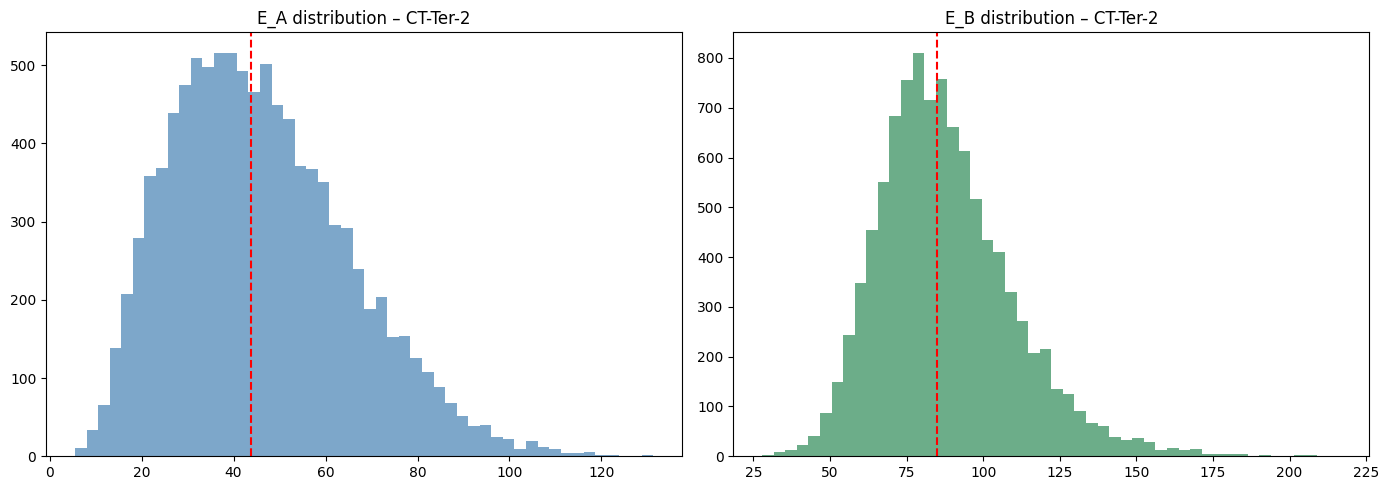



Running CT-Ter-10 …



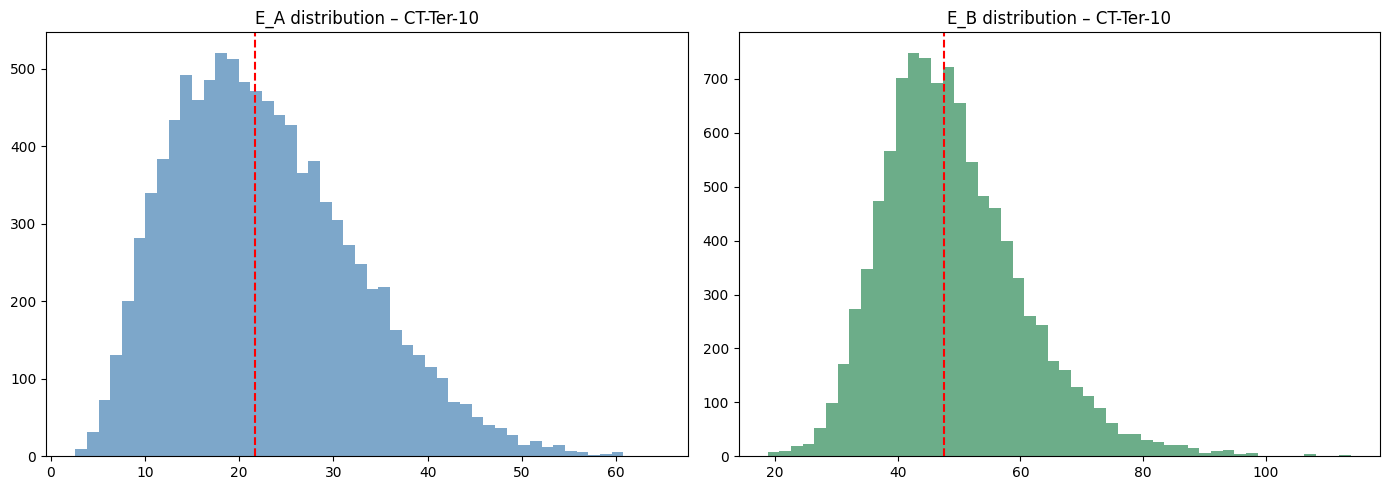

In [7]:
# ============================================================
# ★ PROVIDE MODERN FERTILITY DISTRIBUTIONS (REAL VALUES)
# ============================================================

num_samples = 10000

# -----------------------------
# Zircon fertility ratio CT-8 / CT-3
# median = 0.1682
# IQR = 0.1175 – 0.2598
# -----------------------------
Z_median = 0.1682
Z_q1     = 0.1175
Z_q3     = 0.2598

Z_mu  = np.log(Z_median)
Z_sig = (np.log(Z_q3) - np.log(Z_q1)) / 1.349   # convert IQR to lognormal sigma

Z_A_Z_B_modern = np.random.lognormal(mean=Z_mu, sigma=Z_sig, size=num_samples)


# -----------------------------
# Quartz fertility ratio CT-8 / CT-3
# median = 0.0295
# IQR = 0.0227 – 0.0375
# -----------------------------
Q_median = 0.0295
Q_q1     = 0.0227
Q_q3     = 0.0375

Q_mu  = np.log(Q_median)
Q_sig = (np.log(Q_q3) - np.log(Q_q1)) / 1.349

Q_A_Q_B_modern = np.random.lognormal(mean=Q_mu, sigma=Q_sig, size=num_samples)



# ============================================================
# ★ PALEO EROSION RATES FROM CRONUS (DECAY-CORRECTED)
# ============================================================

# CT-Ter-2 (burial age 1.0 Ma)
E_c_Ter2_mean = 91.6
E_c_Ter2_std  = 8

# CT-Ter-10 (burial age 0.5 Ma)
E_c_Ter10_mean = 49.4
E_c_Ter10_std  = 2.42



# ============================================================
# ★ ZIRCON MIXING WEIGHTS (FROM UPB)
# ============================================================

# CT-Ter-2 mixture = CT-8 (0.683) + CT-3 (0.317)
w_z1_Ter2 = 0.683  # weight for A (CT-8)
w_z2_Ter2 = 0.317  # weight for B (CT-3)

# CT-Ter-10 mixture = CT-8 (0.655) + CT-3 (0.345)
w_z1_Ter10 = 0.655
w_z2_Ter10 = 0.345



# ============================================================
# ★ RUN SOLVER FOR CT-Ter-2
# ============================================================

print("\n\nRunning CT-Ter-2 …\n")
results_Ter2 = solve_paleo_erosion(
    excel_file='/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx',
    paleo_sample_name='CT-Ter-2',
    Q_A_Q_B_samples=Q_A_Q_B_modern,
    Z_A_Z_B_samples=Z_A_Z_B_modern,
    E_c_mean=E_c_Ter2_mean,
    E_c_std=E_c_Ter2_std,
    w_z1=w_z1_Ter2,
    w_z2=w_z2_Ter2,
    num_samples=num_samples,
    random_seed=17
)



# ============================================================
# ★ RUN SOLVER FOR CT-Ter-10
# ============================================================

print("\n\nRunning CT-Ter-10 …\n")
results_Ter10 = solve_paleo_erosion(
    excel_file='/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx',
    paleo_sample_name='CT-Ter-10',
    Q_A_Q_B_samples=Q_A_Q_B_modern,
    Z_A_Z_B_samples=Z_A_Z_B_modern,
    E_c_mean=E_c_Ter10_mean,
    E_c_std=E_c_Ter10_std,
    w_z1=w_z1_Ter10,
    w_z2=w_z2_Ter10,
    num_samples=num_samples,
    random_seed=17
)



===== SUMMARY TABLE =====

Sample  Age (Ma)  Median E_A  Mean E_A   Std E_A  Median E_B  Mean E_B   Std E_B  Valid draws  Total draws
  CT-2       1.0    43.73533 45.983696 19.299408   85.060949 87.841969 22.050586        10000        10000
 CT-10       0.5    21.62199 22.794533  9.765493   47.520685 49.051070 11.607437        10000        10000


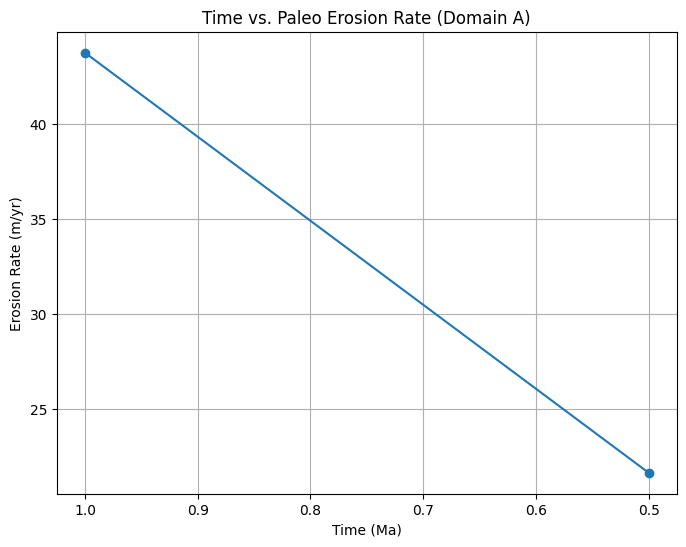

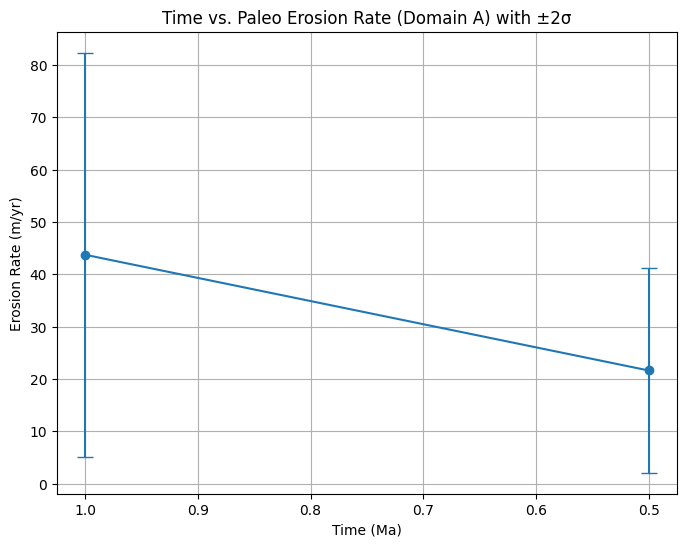

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SUMMARY TABLE FUNCTION
# ============================================================

def summarize(results, sample_name, age_Ma):
    return pd.DataFrame({
        'Sample'      : [sample_name],
        'Age (Ma)'    : [age_Ma],
        'Median E_A'  : [results['E_A_median']],
        'Mean E_A'    : [results['E_A_mean']],
        'Std E_A'     : [results['E_A_std']],
        'Median E_B'  : [results['E_B_median']],
        'Mean E_B'    : [results['E_B_mean']],
        'Std E_B'     : [results['E_B_std']],
        'Valid draws' : [results['n_valid']],
        'Total draws' : [results['n_total']]
    })


# ============================================================
# BUILD SUMMARY TABLES FOR CT-2 AND CT-10
# ============================================================

summary_Ter2  = summarize(results_Ter2,  'CT-2',  1.0)
summary_Ter10 = summarize(results_Ter10, 'CT-10', 0.5)

summary_table = pd.concat([summary_Ter2, summary_Ter10])
print("\n===== SUMMARY TABLE =====\n")
print(summary_table.to_string(index=False))


# ============================================================
# TIME vs EROSION RATE (Median Only)
# ============================================================

times = [1.0, 0.5]  # Ma
E_A_medians = [
    results_Ter2['E_A_median'],
    results_Ter10['E_A_median']
]

plt.figure(figsize=(8,6))
plt.plot(times, E_A_medians, marker='o', linewidth=2)
plt.xlabel("Time (Ma)")
plt.ylabel("Erosion Rate (m/yr)")
plt.title("Time vs. Paleo Erosion Rate (Domain A)")
plt.gca().invert_xaxis()  # older on left
plt.grid(True)
plt.show()


# ============================================================
# TIME vs EROSION RATE (±2σ ERROR BARS)
# ============================================================

E_median = np.array([
    results_Ter2['E_A_median'],
    results_Ter10['E_A_median']
])

E_std = np.array([
    results_Ter2['E_A_std'],
    results_Ter10['E_A_std']
])

plt.figure(figsize=(8,6))
plt.errorbar(times, E_median, yerr=2*E_std, fmt='o-', capsize=6)
plt.xlabel("Time (Ma)")
plt.ylabel("Erosion Rate (m/yr)")
plt.title("Time vs. Paleo Erosion Rate (Domain A) with ±2σ")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()